# 260311/dl/11_거울아 거울아, 나는 멍멍이 상이니, 아니면 냥이 상이니?

## 환경설정

In [3]:
import sys
print(sys.executable)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
print("np", np.__version__)
print("plt OK", plt is not None)
print("tf", tf.__version__)
print("tfds", tfds.__version__)

/usr/bin/python3
np 2.2.6
plt OK True
tf 2.21.0
tfds 4.9.9


In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# 선택된 디바이스 요약
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

TF version: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1612281520606150140
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14006878208
locality {
  bus_id: 1
  links {
  }
}
incarnation: 7168247843530460618
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a"
xla_global_id: 416903419
]


W0000 00:00:1773222787.131089    4071 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1773222787.133685    4071 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773222787.295041    4071 gpu_device.cc:2043] Created device /device:GPU:0 with 13358 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
import tensorflow as tf
print(tf.__version__)

2.21.0


## 데이터로드
- `tensorflow_datasets` 패키지로 데이터 로드 
- [https://www.tensorflow.org/datasets/catalog/overview](https://www.tensorflow.org/datasets/catalog/overview)

In [7]:
import tensorflow_datasets as tfds
tfds.__version__

'4.9.9'

In [10]:
import tensorflow_datasets as tfds
# 컨테이너 내부 경로에 TFDS가 알아서 저장
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    name="cats_vs_dogs",
    split=["train[:80%]", "train[80%:90%]", "train[90%:]"],
    # data_dir 생략 → 기본 캐시 (/root/tensorflow_datasets 등) 사용
    download=True,          # 처음엔 True, 이미 받았으면 False로 변경 가능
    with_info=True,
    as_supervised=True,
)

Generating splits...:   0%|                                                 | 0/1 [00:00<?, ? splits/s]W0000 00:00:1773223097.838803    4071 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773223097.839189    4071 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13358 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt J

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [11]:
import tensorflow_datasets as tfds
print(tfds.__version__)

print("\n")
print(raw_train)
print(raw_validation)
print(raw_test)

4.9.9


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


## 전처리

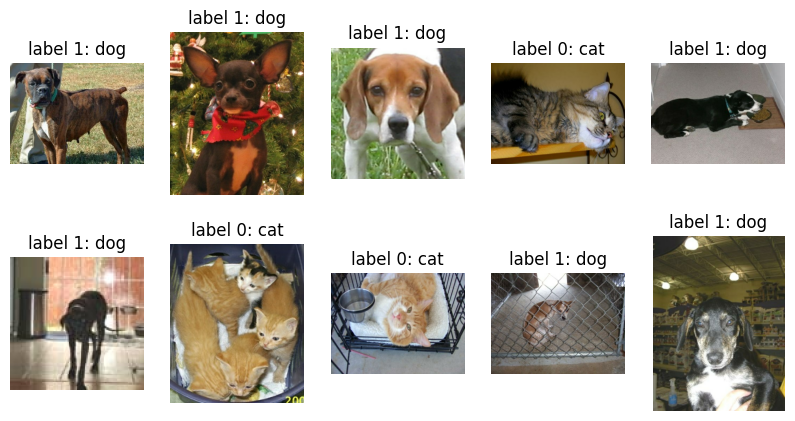

In [ ]:
# raw_train 안에 있는 데이터를 확인해 보기 위해 tf.data.Dataset에서 제공하는 take 함수를 사용
# 강아지는 label 1로, 고양이는 label 0으로 설정


import tensorflow as tf
import matplotlib.pyplot as plt
# %matplotlib inline
# %config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(10, 5))

get_label_name = metadata.features['label'].int2str

for idx, (image, label) in enumerate(raw_train.take(10)):  # 10개의 데이터를 가져 옵니다.
    plt.subplot(2, 5, idx+1)
    plt.imshow(image)
    plt.title(f'label {label}: {get_label_name(label)}')
    plt.axis('off')

In [ ]:
# 이미지의 사이즈는 전부 제각각
# format_example() 함수를 이용해 이미지를 같은 포맷으로 통일
# 아래 코드는 이미지의 사이즈를 160x160 픽셀로 통일시킬 뿐만 아니라, 
# 각 픽셀값의 scale을 수정해주는 역할도 함 

IMG_SIZE = 160 # 리사이징할 이미지의 크기

def format_example(image, label):
    image = tf.cast(image, tf.float32)  # image=float(image)같은 타입캐스팅의  텐서플로우 버전입니다.
    image = (image/127.5) - 1 # 픽셀값의 scale 수정
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

# IMG_SIZE를 160으로 지정해 줌으로써, 모든 이미지의 크기를 (160, 160, 3)으로 통일
train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)

print(train)
print(validation)
print(test)

<_MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


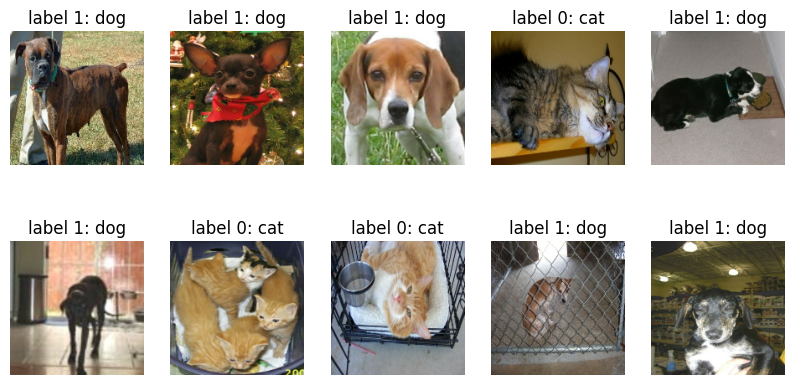

In [19]:
# 리사이징 이후 크기 확인
plt.figure(figsize=(10, 5))

get_label_name = metadata.features['label'].int2str

for idx, (image, label) in enumerate(train.take(10)):
    plt.subplot(2, 5, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    plt.title(f'label {label}: {get_label_name(label)}')
    plt.axis('off')

## 모델 구조 설계 

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

model = Sequential([
    Conv2D(filters=16, kernel_size=3, padding='same', activation='relu', input_shape=(160, 160, 3)),
    MaxPooling2D(),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(units=512, activation='relu'),
    Dense(units=2, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 160, 160, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 80, 80, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 80, 80, 32)        4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 40, 40, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 40, 40, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 20, 20, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 25600)            

## 모델 compile 및 학습

In [21]:
learning_rate = 0.0001

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

# 한 스텝에 학습시킬 데이터의 개수인 BATCH_SIZE와 
# 학습 데이터를 적절히 섞어줄 SHUFFLE_BUFFER_SIZE를 설정
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

# BATCH_SIZE에 따라 
# 32개 데이터를 랜덤으로 뿌려줄 
# train_batches,  validation_batches,test_batches 생성
train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)

# train_batches에서 하나의 batch만 꺼내 데이터를 확인
for image_batch, label_batch in train_batches.take(1):
    break

image_batch.shape, label_batch.shape


(TensorShape([32, 160, 160, 3]), TensorShape([32]))

In [22]:
# 학습전 모델 성능 확인
validation_steps = 20
loss0, accuracy0 = model.evaluate(validation_batches, steps=validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

I0000 00:00:1773224092.023248    4199 service.cc:153] XLA service 0x784b0002fca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773224092.023443    4199 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773224092.054360    4199 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773224092.983909    4199 cuda_dnn.cc:461] Loaded cuDNN version 92000


13/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5425 - loss: 0.6887

I0000 00:00:1773224095.230292    4199 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5266 - loss: 0.6937
initial loss: 0.69
initial accuracy: 0.53


In [23]:
# 학습 수행
EPOCHS = 10
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)

Epoch 1/10


I0000 00:00:1773224118.678425    4196 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71933__.39


580/582 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6205 - loss: 0.6585

I0000 00:00:1773224136.433808    4197 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71933__.39


582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6206 - loss: 0.6583

I0000 00:00:1773224142.286802    5598 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 20 bytes spill stores, 20 bytes spill loads



582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6627 - loss: 0.6093 - val_accuracy: 0.7279 - val_loss: 0.5529
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7517 - loss: 0.5078 - val_accuracy: 0.7631 - val_loss: 0.5032
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7931 - loss: 0.4483 - val_accuracy: 0.7128 - val_loss: 0.5830
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8189 - loss: 0.3987 - val_accuracy: 0.7803 - val_loss: 0.4665
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8479 - loss: 0.3512 - val_accuracy: 0.7850 - val_loss: 0.4624
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8735 - loss: 0.3027 - val_accuracy: 0.7833 - val_loss: 0.4781
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8998 - loss: 0.2495 - val_accuracy: 0.7876 - val_loss: 0.4942
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9265 - loss: 0.1942 - val_accurac

## 모델 학습곡선 확인 및 예측 결과 시각화

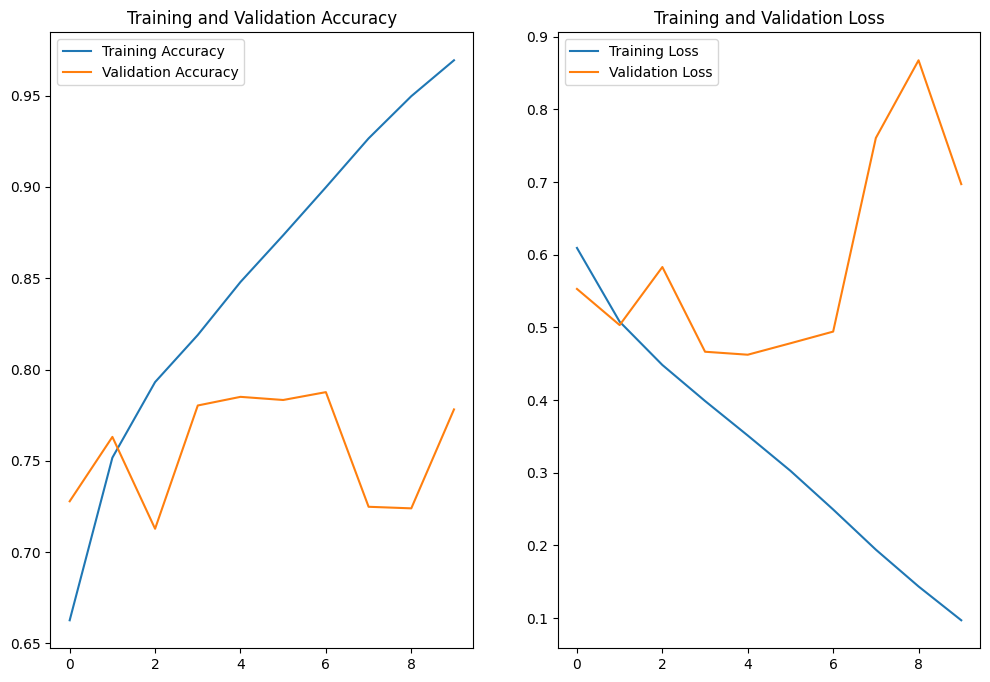

In [ ]:
# 학습 단계에 따른 정확도 변화 그래프

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [25]:
# 모델의 예측 결과를 확인하고 싶을 때는 다음과 같이 model.predict를 활용
for image_batch, label_batch in test_batches.take(1):
    images = image_batch
    labels = label_batch
    predictions = model.predict(image_batch)
    break

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


array([[9.99962687e-01, 3.73543990e-05],
       [9.46253061e-01, 5.37470095e-02],
       [7.70262703e-02, 9.22973692e-01],
       [9.99691308e-01, 3.08695162e-04],
       [9.25498903e-01, 7.45010823e-02],
       [2.13617623e-01, 7.86382377e-01],
       [2.36296281e-02, 9.76370394e-01],
       [7.18632162e-01, 2.81367838e-01],
       [1.10857496e-02, 9.88914311e-01],
       [3.26171964e-02, 9.67382848e-01],
       [1.66837409e-01, 8.33162606e-01],
       [9.96647179e-01, 3.35281575e-03],
       [9.91487265e-01, 8.51275492e-03],
       [1.05461650e-05, 9.99989510e-01],
       [8.88466835e-01, 1.11533180e-01],
       [9.96832669e-01, 3.16730654e-03],
       [9.93845761e-01, 6.15417259e-03],
       [5.59307635e-01, 4.40692365e-01],
       [1.84012532e-01, 8.15987468e-01],
       [3.55837010e-02, 9.64416325e-01],
       [9.99671638e-01, 3.28340306e-04],
       [9.72388387e-01, 2.76116095e-02],
       [8.38106751e-01, 1.61893263e-01],
       [3.39853554e-03, 9.96601462e-01],
       [6.405355

In [26]:
# prediction 값들을 실제 추론한 라벨(고양이:0, 강아지:1)로 변환
predictions = np.argmax(predictions, axis=1)
predictions

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1])

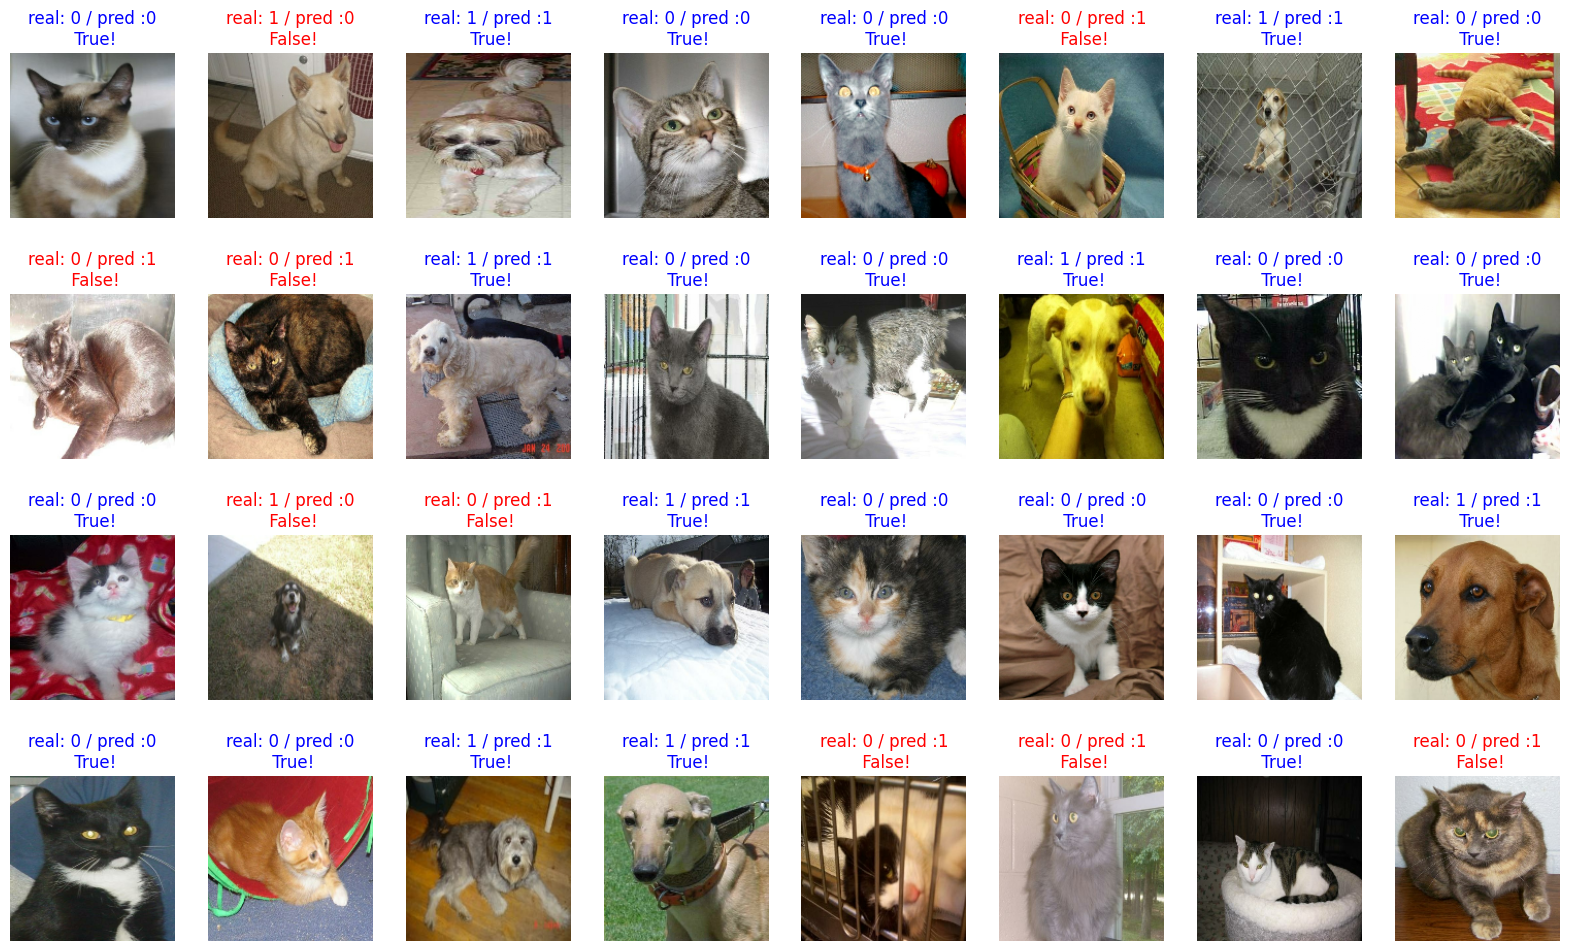

In [27]:
# 32장의 imag, label, prediction을 각각 시각화
plt.figure(figsize=(20, 12))

for idx, (image, label, prediction) in enumerate(zip(images, labels, predictions)):
    plt.subplot(4, 8, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    correct = label == prediction
    title = f'real: {label} / pred :{prediction}\n {correct}!'
    if not correct:
        plt.title(title, fontdict={'color': 'red'})
    else:
        plt.title(title, fontdict={'color': 'blue'})
    plt.axis('off')

In [ ]:
count = 0   # 정답을 맞춘 개수
for image, label, prediction in zip(images, labels, predictions):
    if label == prediction:
        count += 1
print(count / 32 * 100)

71.875


## VGG16 로딩 및 모델 구조 확인

In [36]:
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Create the base model from the pre-trained model VGG16
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                         include_top=False,
                                         weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [37]:
image_batch.shape

TensorShape([32, 160, 160, 3])

In [38]:
feature_batch = base_model(image_batch)
feature_batch.shape

TensorShape([32, 5, 5, 512])

In [39]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 160, 160, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 160, 160, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 80, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 40, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 20, 20, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## VGG16 커스터 마이징 


In [40]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 512)


In [41]:
# dense layer에는 unit과 activation 2개의 매개변수만 사용해주세요.
# unit의 값은 위에서 global_average_layer를 통과했을 때의 값을 생각해보세요.
# 활성화 함수는 ReLU를 사용합니다.
dense_layer = tf.keras.layers.Dense(units=512, activation='relu') 
# unit은 우리가 분류하고 싶은 class를 생각해보세요.
# 활성화 함수는 Softmax를 사용합니다.
prediction_layer = tf.keras.layers.Dense(units=2, activation='softmax') 

# feature_batch_averag가 dense_layer를 거친 결과가 다시 prediction_layer를 거치게 되면
prediction_batch = prediction_layer(dense_layer(feature_batch_average))  
print(prediction_batch.shape)

(32, 2)


In [42]:
base_model.trainable = False

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  prediction_layer])
  
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,370 (57.14 MB)

 Trainable params: 263,682 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [49]:
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 512)


In [ ]:
# dense layer에는 unit과 activation 2개의 매개변수만 사용해주세요.
# unit의 값은 위에서 global_average_layer를 통과했을 때의 값을 생각해보세요.
# 활성화 함수는 ReLU를 사용합니다.
dense_layer = tf.keras.layers.Dense(units=512, activation='relu') 
# unit은 우리가 분류하고 싶은 class를 생각해보세요.
# 활성화 함수는 Softmax를 사용합니다.
prediction_layer = tf.keras.layers.Dense(units=2, activation='softmax') 

# feature_batch_averag가 dense_layer를 거친 결과가 다시 prediction_layer를 거치게 되면
prediction_batch = prediction_layer(dense_layer(feature_batch_average))  
print(prediction_batch.shape)

(32, 2)


In [56]:
base_model.trainable = False

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  prediction_layer
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 5, 5, 512)         14714688  
_________________________________________________________________
global_average_pooling2d (Gl (None, 512)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 1280)              656640    
_________________________________________________________________
dense_5 (Dense)              (None, 2)                 2562      
Total params: 15,373,890
Trainable params: 659,202
Non-trainable params: 14,714,688
_________________________________________________________________


## 컴파일 및 학습

In [43]:
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.4812 - loss: 0.7546
initial loss: 0.75
initial accuracy: 0.48


In [44]:
EPOCHS = 5 
history = model.fit(
    train_batches,           # train_dataset → train_batches
    epochs=EPOCHS,
    validation_data=validation_batches   # validation_dataset → validation_batches
)

Epoch 1/5


I0000 00:00:1773226216.921195    4199 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101904__.66


581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8501 - loss: 0.3721

I0000 00:00:1773226243.682429    4199 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101904__.66


582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.9028 - loss: 0.2618 - val_accuracy: 0.9312 - val_loss: 0.1747
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9348 - loss: 0.1616 - val_accuracy: 0.9304 - val_loss: 0.1639
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9414 - loss: 0.1451 - val_accuracy: 0.9377 - val_loss: 0.1548
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9428 - loss: 0.1377 - val_accuracy: 0.9407 - val_loss: 0.1425
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9460 - loss: 0.1324 - val_accuracy: 0.9394 - val_loss: 0.1483


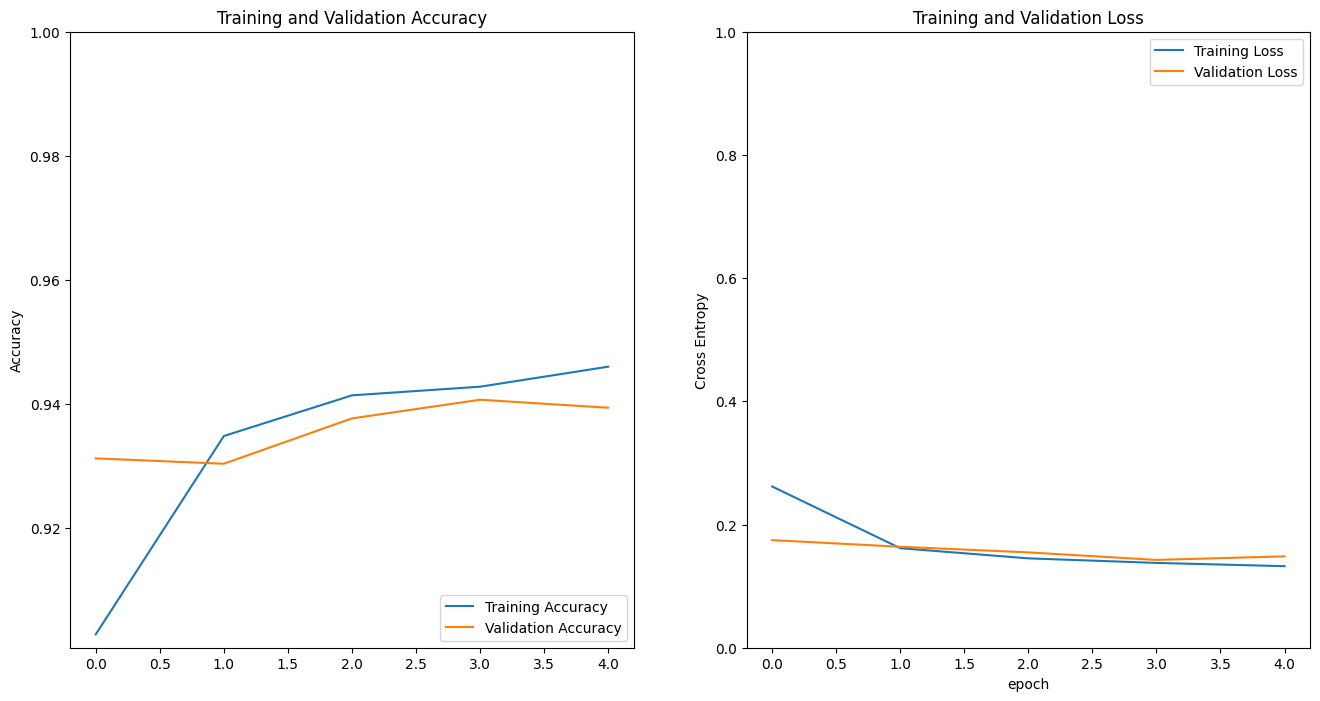

In [46]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [47]:
# 샘플을 test_batches에서 가져와서 예측 결과만들기
for image_batch, label_batch in test_batches.take(1):
    images = image_batch
    labels = label_batch
    predictions = model.predict(image_batch)
    pass

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step


array([[9.99949694e-01, 5.03483752e-05],
       [9.50802937e-02, 9.04919744e-01],
       [1.62062153e-01, 8.37937772e-01],
       [9.99980569e-01, 1.94728327e-05],
       [9.95075524e-01, 4.92453389e-03],
       [9.61609483e-01, 3.83905098e-02],
       [9.98963005e-05, 9.99900103e-01],
       [5.17809689e-01, 4.82190341e-01],
       [9.40089047e-01, 5.99109605e-02],
       [9.35057878e-01, 6.49421141e-02],
       [3.66264758e-05, 9.99963403e-01],
       [9.99788761e-01, 2.11178223e-04],
       [9.79506135e-01, 2.04938464e-02],
       [4.87310081e-06, 9.99995112e-01],
       [9.96028721e-01, 3.97125678e-03],
       [9.66297030e-01, 3.37029286e-02],
       [8.99361134e-01, 1.00638956e-01],
       [7.69289210e-02, 9.23071086e-01],
       [9.01960313e-01, 9.80396569e-02],
       [1.66904568e-09, 1.00000000e+00],
       [9.98692572e-01, 1.30743906e-03],
       [9.99598384e-01, 4.01580764e-04],
       [9.66680527e-01, 3.33194658e-02],
       [1.72898609e-07, 9.99999881e-01],
       [9.991526

In [48]:
# 이번에도 prediction 값들을 실제 추론한 라벨(고양이:0, 강아지:1)로 변환
import numpy as np
predictions = np.argmax(predictions, axis=1)
predictions

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0])

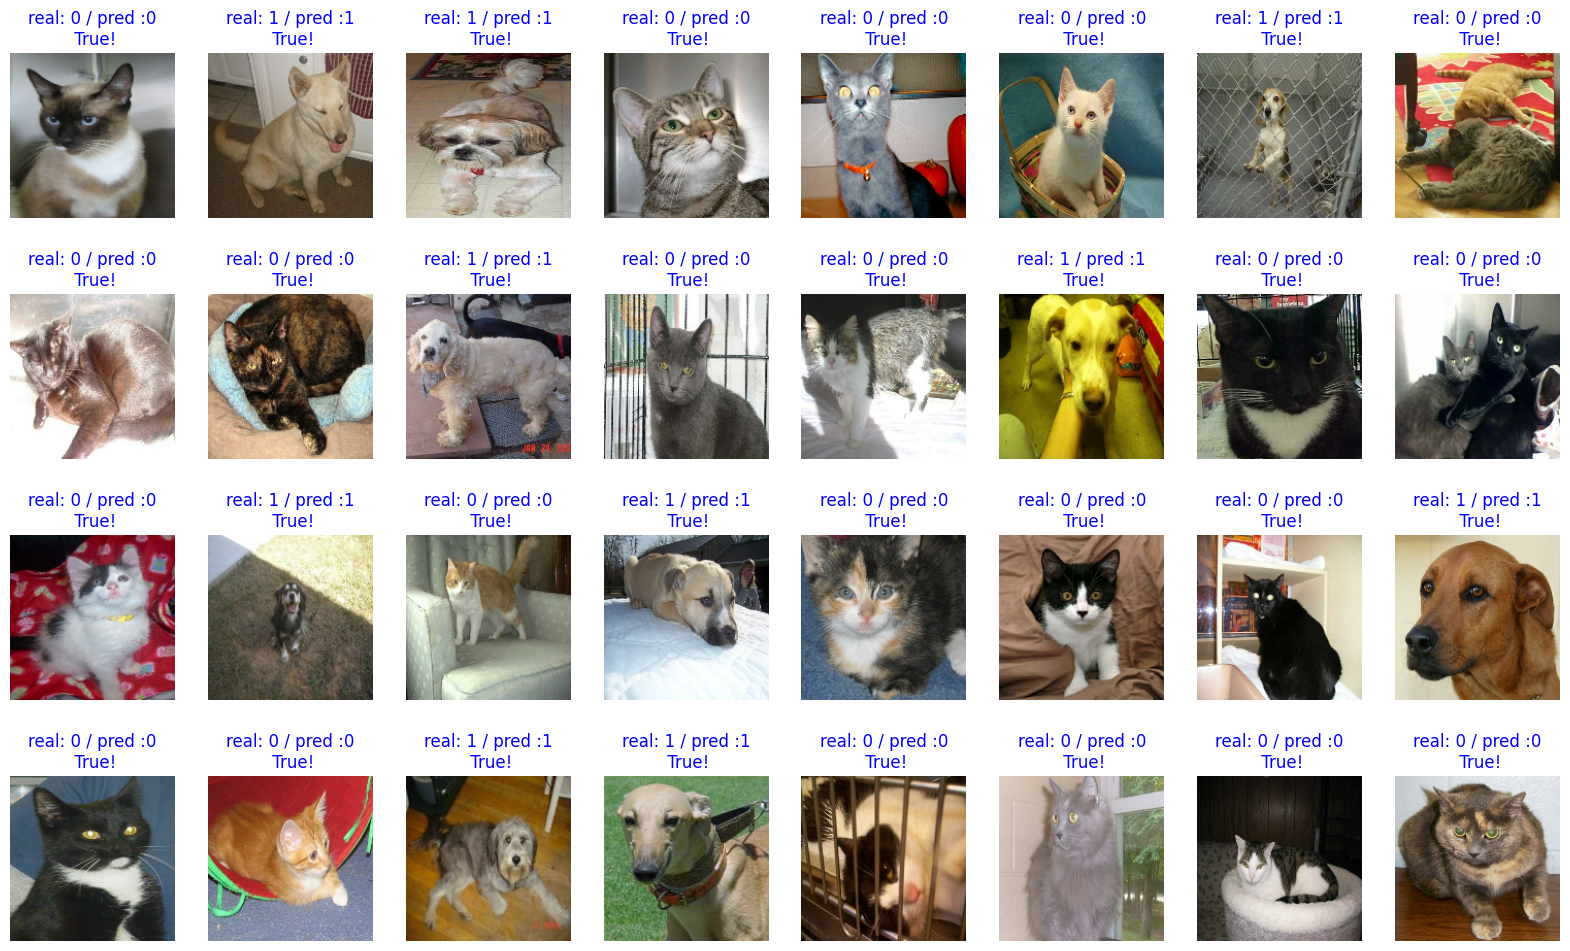

In [49]:
plt.figure(figsize=(20, 12))

for idx, (image, label, prediction) in enumerate(zip(images, labels, predictions)):
    plt.subplot(4, 8, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    correct = label == prediction
    title = f'real: {label} / pred :{prediction}\n {correct}!'
    if not correct:
        plt.title(title, fontdict={'color': 'red'})
    else:
        plt.title(title, fontdict={'color': 'blue'})
    plt.axis('off')

In [50]:
#  32개에 대한 정확도를 확인
count = 0
for image, label, prediction in zip(images, labels, predictions):
    correct = label == prediction
    if correct:
        count = count + 1

print(count / 32 * 100) # 약 95% 내외

100.0


## 모델 save/load 

In [ ]:
import os

checkpoint_dir = os.getenv("HOME") + "D:\git\01_mdls_ds8_open\08_dl\260311_dl_minipjt\epoch_save"
checkpoint_file_path = os.path.join(checkpoint_dir, 'checkpoint')

if not os.path.exists('checkpoint_dir'):
    os.mkdir('checkpoint_dir')
    
model.save_weights(checkpoint_file_path)     # checkpoint 파일 생성

if os.path.exists(checkpoint_file_path):
  print('checkpoint 파일 생성 OK!!')

## 학습된 모델에 원하는 이미지를 입력해 예측 결과 확인

In [45]:
# 프리픽([Freepik](https://www.freepik.com/))에서 구해온 강아지와 고양이의 이미지를 넣어보도록 하겠습니다. 잘 맞출지, 기대가 되는군요! 
# 아래 명령어를 통해 준비된 이미지를 연결해 주세요.
# !ln -s ~/data/* ~/aiffel/cat_vs_dog/images/

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 160
img_dir_path = os.getenv("HOME") + "/aiffel/cat_vs_dog/images"
dog_image_path = os.path.join(img_dir_path, 'my_dog.jpg')

dog_image = load_img(dog_image_path, target_size=(IMG_SIZE, IMG_SIZE))
dog_image


dog_image = img_to_array(dog_image).reshape(1, IMG_SIZE, IMG_SIZE, 3)
dog_image.shape

prediction = model.predict(dog_image)
prediction

def show_and_predict_image(dirpath, filename, img_size=160):
    filepath = os.path.join(dirpath, filename)
    image = load_img(filepath, target_size=(img_size, img_size))
    plt.imshow(image)
    plt.axis('off')
    image = img_to_array(image).reshape(1, img_size, img_size, 3)
    prediction = model.predict(image)[0]
    cat_percentage = round(prediction[0] * 100)
    dog_percentage = round(prediction[1] * 100)
    print(f"This image seems {dog_percentage}% dog, and {cat_percentage}% cat.")


filename = 'my_dog.jpg'
show_and_predict_image(img_dir_path, filename)
filename = 'my_cat.jpg'
show_and_predict_image(img_dir_path, filename)